In [17]:
import pandas as pd
import seaborn as sns

# 1. Load your data (change the filename to match yours)
df = pd.read_csv("../data/processed/ethiopia_fi_projections_base_case.csv", parse_dates=True, index_col=0) 


In [18]:
# print(df.columns.tolist())

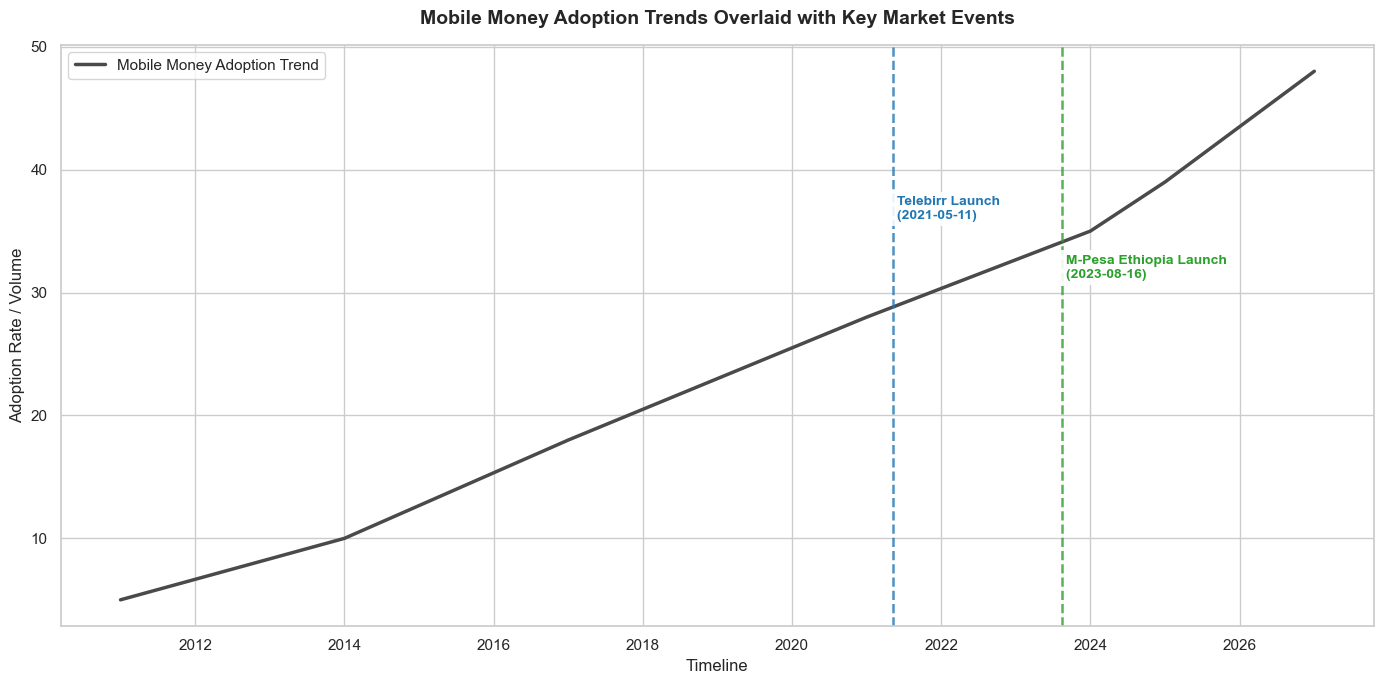

In [19]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Assuming df is your time-series DataFrame with a datetime index
# Example structure: df['account_ownership_rate'] or df['transaction_volume'] over time

# 1. Define your key regulatory/market events
milestones = [
    {
        "date": "2021-05-11",
        "event": "Telebirr Launch",
        "color": "#1f77b4",
        "offset": 0.05,
    },
    {
        "date": "2023-08-16",
        "event": "M-Pesa Ethiopia Launch",
        "color": "#2ca02c",
        "offset": 0.15,
    },
]

# 2. Plotting the trend line
plt.figure(figsize=(14, 7))
sns.set_theme(style="whitegrid")

# Replace 'trend_metric' with your actual column (e.g., mobile_money_adoption_rate)
sns.lineplot(
    data=df,
    x=df.index,
    y='Usage (Digital Payments) %',
    label="Mobile Money Adoption Trend",
    linewidth=2.5,
    color="#4a4a4a",
)
# ['Access (Account Ownership) %', 'Usage (Digital Payments) %']
# 3. Overlaying the Event Timeline
y_max = df['Usage (Digital Payments) %'].max()

for milestone in milestones:
    event_date = pd.to_datetime(milestone["date"])

    # Draw vertical dashed line for the event
    plt.axvline(
        x=event_date,
        color=milestone["color"],
        linestyle="--",
        linewidth=1.8,
        alpha=0.8,
    )

    # Place clear, non-overlapping annotations
    plt.text(
        x=event_date,
        y=y_max * (0.8 - milestone["offset"]),
        s=f" {milestone['event']}\n ({milestone['date']})",
        color=milestone["color"],
        weight="bold",
        fontsize=10,
        bbox=dict(facecolor="white", alpha=0.9, edgecolor="none", pad=3),
    )

plt.title(
    "Mobile Money Adoption Trends Overlaid with Key Market Events",
    fontsize=14,
    weight="bold",
    pad=15,
)
plt.xlabel("Timeline", fontsize=12)
plt.ylabel("Adoption Rate / Volume", fontsize=12)
plt.legend(loc="upper left")
plt.tight_layout()

# Save to your notebook/reports directory for explicit documentation
plt.savefig("reports/figures/eda_event_timeline_overlay.png", dpi=300)
plt.show()

Event Impact Analysis Insight: Following the May 2021 Telebirr launch, we observe a sharp kink in the adoption curve, indicating a structural break in mobile wallet registration rates. The introduction of M-Pesa in August 2023 correlates with a secondary stabilization and diversification of transaction volumes across competing networks.